Train shape: (60000, 28, 28)
Train labels: (60000,)
Test shape: (10000, 28, 28)
Test labels: (10000,)


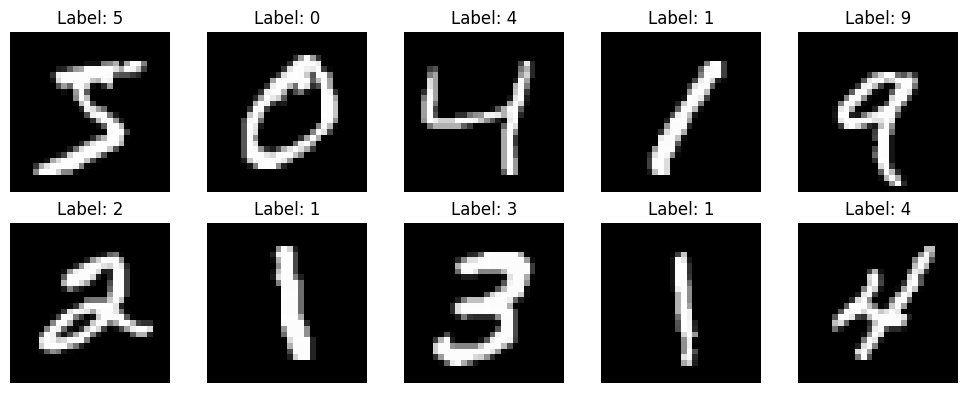

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

train_images = load_mnist_images('MNIST/train-images-idx3-ubyte')
train_labels = load_mnist_labels('MNIST/train-labels-idx1-ubyte')
test_images = load_mnist_images('MNIST/t10k-images-idx3-ubyte')
test_labels = load_mnist_labels('MNIST/t10k-labels-idx1-ubyte')

print(f'Train shape: {train_images.shape}')
print(f'Train labels: {train_labels.shape}')
print(f'Test shape: {test_images.shape}')
print(f'Test labels: {test_labels.shape}')

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_images[i], cmap='gray')
    ax.set_title(f'Label: {train_labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [2]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

train_images = (train_images.astype(np.float32) / 255.0).reshape(-1, 1, 28, 28)
test_images = (test_images.astype(np.float32) / 255.0).reshape(-1, 1, 28, 28)

train_tensor = torch.tensor(train_images)
test_tensor = torch.tensor(test_images)

train_loader = DataLoader(TensorDataset(train_tensor, train_tensor), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(test_tensor, test_tensor), batch_size=128, shuffle=False)

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7), nn.ReLU(),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=1, padding=1), nn.Sigmoid()
        )
    
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed
    
device = torch.device('mps')
model = Autoencoder(latent_dim=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Обучение:

Loss value: 0.0082130199
Output range: min=0.0000, max=0.9963
Input range: min=0.0000, max=1.0000
Epoch [1/20] - Train Loss: 0.0382, Test Loss: 0.0103
Epoch [2/20] - Train Loss: 0.0081, Test Loss: 0.0067
Epoch [3/20] - Train Loss: 0.0061, Test Loss: 0.0055
Epoch [4/20] - Train Loss: 0.0054, Test Loss: 0.0050
Epoch [5/20] - Train Loss: 0.0049, Test Loss: 0.0047
Epoch [6/20] - Train Loss: 0.0046, Test Loss: 0.0045
Epoch [7/20] - Train Loss: 0.0044, Test Loss: 0.0044
Epoch [8/20] - Train Loss: 0.0042, Test Loss: 0.0041
Epoch [9/20] - Train Loss: 0.0040, Test Loss: 0.0040
Epoch [10/20] - Train Loss: 0.0039, Test Loss: 0.0039
Epoch [11/20] - Train Loss: 0.0038, Test Loss: 0.0038
Epoch [12/20] - Train Loss: 0.0037, Test Loss: 0.0037
Epoch [13/20] - Train Loss: 0.0036, Test Loss: 0.0036
Epoch [14/20] - Train Loss: 0.0036, Test Loss: 0.0036
Epoch [15/20] - Train Loss: 0.0035, Test Loss: 0.0035
Epoch [16/20] - Train Loss: 0.0034, Test Loss: 0.0035
Epoch [17/20] - Train Loss: 0.0034, Test Loss: 

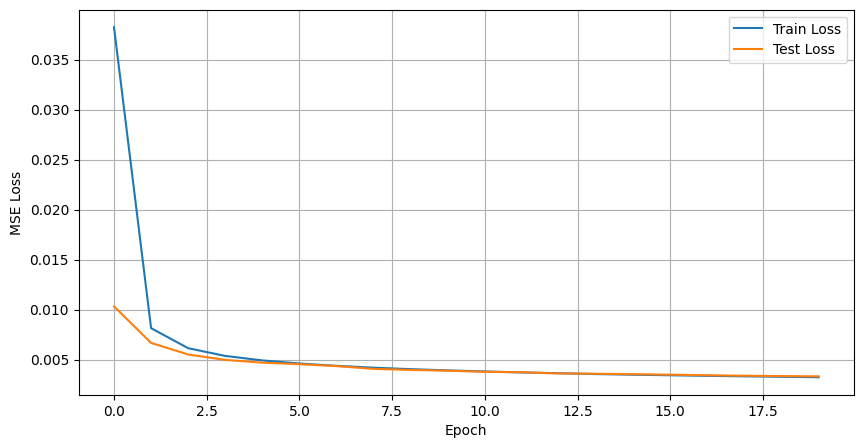

In [3]:
num_epochs = 20
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_x)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    model.eval()
    epoch_test_loss = 0
    with torch.no_grad():
        for batch_x, _ in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_x)
            epoch_test_loss += loss.item()
    
    train_losses.append(epoch_train_loss / len(train_loader))
    test_losses.append(epoch_test_loss / len(test_loader))
    
    if epoch == 0:
        print(f'Loss value: {loss.item():.10f}')
        print(f'Output range: min={outputs.min().item():.4f}, max={outputs.max().item():.4f}')
        print(f'Input range: min={batch_x.min().item():.4f}, max={batch_x.max().item():.4f}')
    print(f'Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

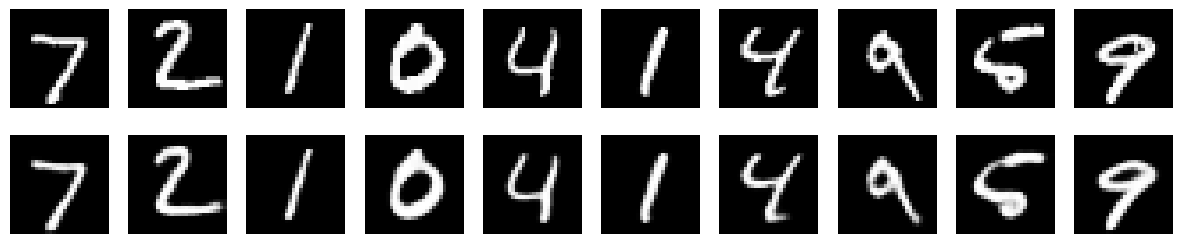

In [5]:
model.eval()
with torch.no_grad():
    test_batch, _ = next(iter(test_loader))
    test_batch = test_batch[:10].to(device)
    reconstructed = model(test_batch)
    
    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        axes[0, i].imshow(test_batch[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')
    
    plt.show()

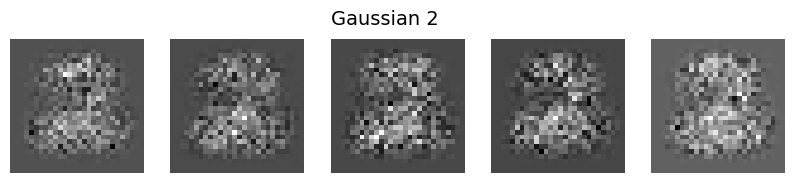

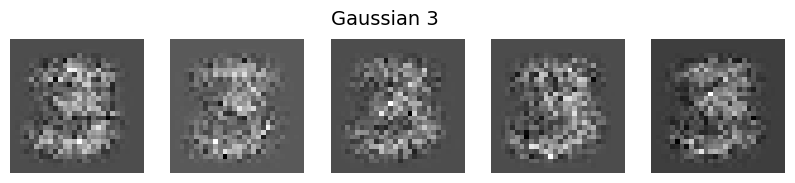

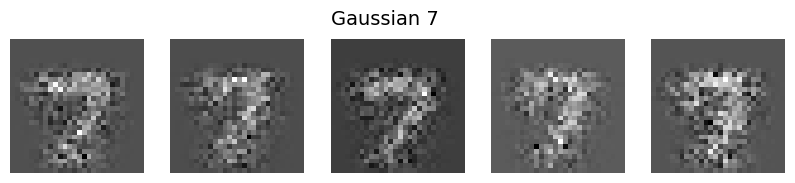

In [12]:
for digit in 2, 3, 7:
    digit_indices = train_labels == digit
    digit_images = train_images.reshape(train_images.shape[0], -1)[digit_indices]

    mean_vector = digit_images.mean(axis=0)
    std_vector = digit_images.std(axis=0)

    generated_noise = np.random.randn(5, 784) * std_vector + mean_vector
    generated_images = generated_noise.reshape(5, 28, 28)

    fig, axes = plt.subplots(1, 5, figsize=(10, 2))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i], cmap='gray')
        ax.axis('off')
    plt.suptitle(f'Gaussian {digit}', fontsize=14)
    plt.show()

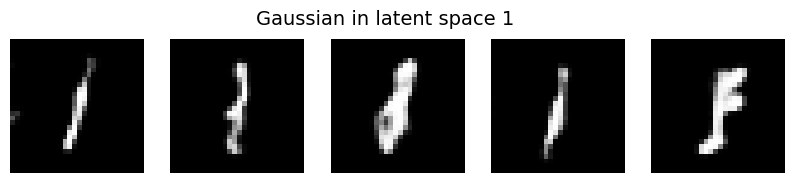

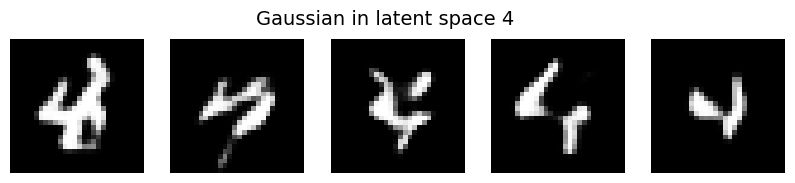

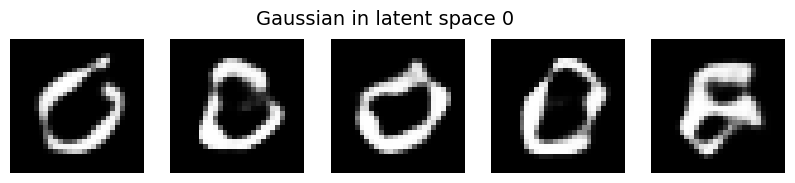

In [25]:
model.eval()
with torch.no_grad():
    train_latents = model.encoder(torch.tensor(train_images).to(device)).cpu().numpy()

for digit in 1, 4, 0:
    digit_indices = train_labels == digit
    digit_latents = train_latents[digit_indices]
    
    mean_vector = digit_latents.mean(axis=0)
    std_vector = digit_latents.std(axis=0)
    
    generated_latents = np.random.randn(5, 32) * std_vector + mean_vector
    generated_latents = torch.tensor(generated_latents, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        generated_images = model.decoder(generated_latents).cpu().numpy().reshape(5, 28, 28)
    
    fig, axes = plt.subplots(1, 5, figsize=(10, 2))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i], cmap='gray')
        ax.axis('off')
    plt.suptitle(f'Gaussian in latent space {digit}', fontsize=14)
    plt.show()

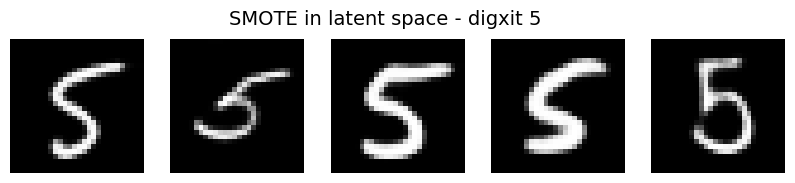

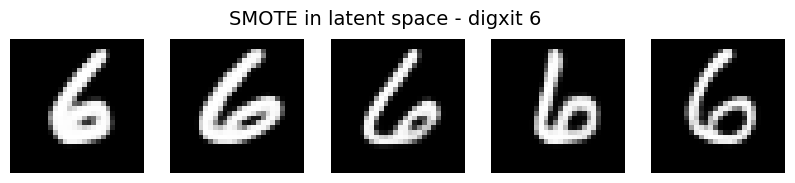

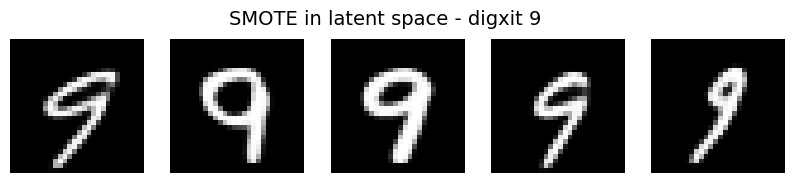

In [61]:
from sklearn.neighbors import NearestNeighbors

def smote_latent(class_id, n_samples, k=5):
    class_indices = train_labels == class_id
    class_latents = train_latents[class_indices]
    
    nn = NearestNeighbors(n_neighbors=min(k+1, len(class_latents)))
    nn.fit(class_latents)
    
    generated_latents = []
    for _ in range(n_samples):
        idx = np.random.randint(len(class_latents))
        _, indices = nn.kneighbors(class_latents[idx:idx+1], n_neighbors=min(k+1, len(class_latents)))
        
        neighbor_idx = indices[0][np.random.randint(1, len(indices[0]))]
        
        alpha = np.random.random()
        new_latent = class_latents[idx] + alpha * (class_latents[neighbor_idx] - class_latents[idx])
        generated_latents.append(new_latent)
    
    generated_latents = np.array(generated_latents)
    generated_latents = torch.tensor(generated_latents, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        generated_images = model.decoder(generated_latents).cpu().numpy().reshape(n_samples, 28, 28)
    
    return generated_images

for digit in 5, 6, 9:
    generated = smote_latent(digit, 5, k=3)
    
    fig, axes = plt.subplots(1, 5, figsize=(10, 2))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i], cmap='gray')
        ax.axis('off')
    plt.suptitle(f'SMOTE in latent space - digxit {digit}', fontsize=14)
    plt.show()

Epoch 1/10, Loss: 0.167011
Epoch 2/10, Loss: 0.075331
Epoch 3/10, Loss: 0.065146
Epoch 4/10, Loss: 0.059575
Epoch 5/10, Loss: 0.055565
Epoch 6/10, Loss: 0.052794
Epoch 7/10, Loss: 0.051162
Epoch 8/10, Loss: 0.049318
Epoch 9/10, Loss: 0.048389
Epoch 10/10, Loss: 0.047767


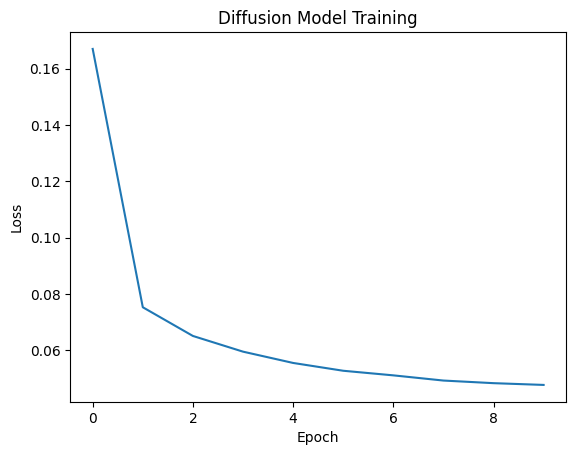

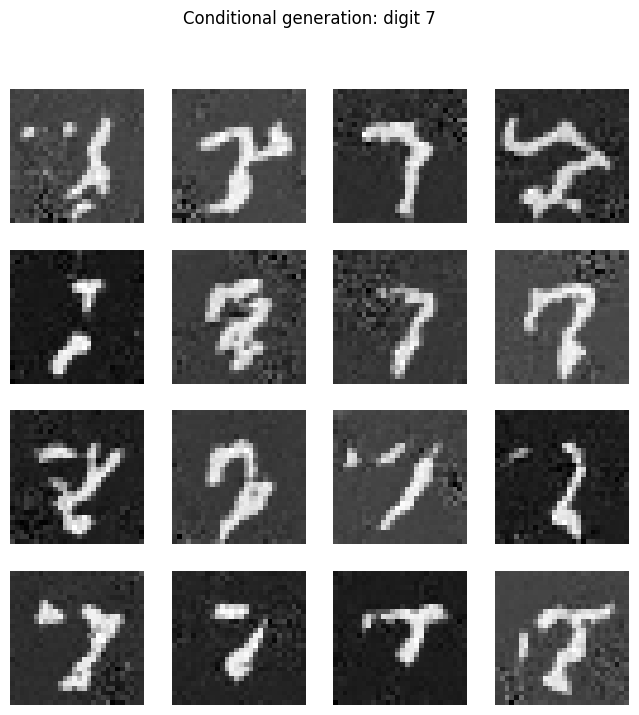

In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

class DiffusionModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, 28 * 28)
        self.net = nn.Sequential(
            nn.Conv2d(2, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 1, 3, padding=1)
        )

    def forward(self, x, t, y):
        label_map = self.label_emb(y).view(-1, 1, 28, 28)
        x = torch.cat([x, label_map], dim=1)
        return self.net(x)

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)

timesteps = 300
betas = linear_beta_schedule(timesteps)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

device = torch.device('mps')

betas = betas.to(device)
alphas = alphas.to(device)
alphas_cumprod = alphas_cumprod.to(device)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)

def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start)
    sqrt_alphas_cumprod_t = sqrt_alphas_cumprod[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1)
    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

diffusion = DiffusionModel().to(device)
optimizer = optim.Adam(diffusion.parameters(), lr=0.001)

batch_size = 256
train_loader_diff = DataLoader(
    TensorDataset(
        torch.tensor(train_images, dtype=torch.float32),
        torch.tensor(train_labels, dtype=torch.long)
    ),
    batch_size=batch_size,
    shuffle=True
)

num_epochs = 10
losses = []

for epoch in range(num_epochs):
    epoch_loss = 0
    for batch in train_loader_diff:
        x = batch[0].to(device)
        y = batch[1].to(device)
        t = torch.randint(0, timesteps, (x.shape[0],), device=device)
        noise = torch.randn_like(x)
        x_noisy = q_sample(x, t, noise)
        noise_pred = diffusion(x_noisy, t, y)
        loss = nn.MSELoss()(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader_diff)
    losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}')

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Diffusion Model Training')
plt.show()

@torch.no_grad()
def p_sample_cond(model, x, t, y):
    betas_t = betas[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1)
    sqrt_recip_alphas_t = torch.sqrt(1.0 / alphas[t]).reshape(-1, 1, 1, 1)
    noise_pred = model(x, t, y)
    x = sqrt_recip_alphas_t * (x - betas_t / sqrt_one_minus_alphas_cumprod_t * noise_pred)
    if t[0] > 0:
        x = x + torch.sqrt(betas_t) * torch.randn_like(x)
    return x

@torch.no_grad()
def generate_class(model, digit, n_samples=16):
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28).to(device)
    y = torch.full((n_samples,), digit, device=device, dtype=torch.long)
    for t in reversed(range(timesteps)):
        t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)
        x = p_sample_cond(model, x, t_tensor, y)
    return x.cpu()

digit = 7
generated = generate_class(diffusion, digit, n_samples=16)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i, 0], cmap='gray')
    ax.axis('off')
plt.suptitle(f'Conditional generation: digit {digit}')
plt.show()

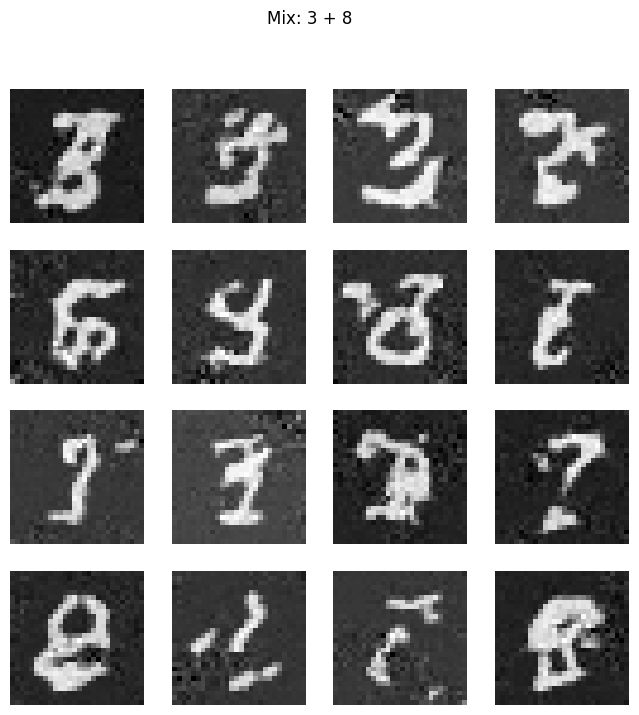

In [ ]:
@torch.no_grad()
def generate_mixed_classes(model, digit_a, digit_b, alpha=0.5, n_samples=16):
    model.eval()
    x = torch.randn(n_samples, 1, 28, 28).to(device)
    y_a = torch.full((n_samples,), digit_a, device=device, dtype=torch.long)
    y_b = torch.full((n_samples,), digit_b, device=device, dtype=torch.long)

    for t in reversed(range(timesteps)):
        t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)
        noise_a = model(x, t_tensor, y_a)
        noise_b = model(x, t_tensor, y_b)
        noise_pred = alpha * noise_a + (1 - alpha) * noise_b
        betas_t = betas[t].reshape(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1)
        sqrt_recip_alphas_t = torch.sqrt(1.0 / alphas[t]).reshape(-1, 1, 1, 1)
        x = sqrt_recip_alphas_t * (x - betas_t / sqrt_one_minus_alphas_cumprod_t * noise_pred)
        if t > 0:
            x = x + torch.sqrt(betas_t) * torch.randn_like(x)
    return x.cpu()

mixed = generate_mixed_classes(diffusion, 4, 9, alpha=0.5)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(mixed[i, 0], cmap='gray')
    ax.axis('off')
plt.suptitle('Mix: 3 + 8')
plt.show()